In [1]:
import numpy as np
import os
import tensorflow as tf
from keras.layers import Dense, TimeDistributed
from keras.models import Model
# from custom_CCE_fit import custom_crossentropy
from keras.layers import Layer
import action_seg_models_periodic_padding
from tqdm import tqdm 
from sklearn.model_selection import train_test_split
import csv
from keras.regularizers import l2

2024-11-09 14:43:10.536865: I tensorflow/core/util/port.cc:111] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2024-11-09 14:43:10.585779: E tensorflow/compiler/xla/stream_executor/cuda/cuda_dnn.cc:9342] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2024-11-09 14:43:10.585835: E tensorflow/compiler/xla/stream_executor/cuda/cuda_fft.cc:609] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2024-11-09 14:43:10.585880: E tensorflow/compiler/xla/stream_executor/cuda/cuda_blas.cc:1518] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2024-11-09 14:43:10.595789: I tensorflow/core/platform/cpu_feature_g

In [2]:
# Set up GPU usage
os.environ["CUDA_VISIBLE_DEVICES"] = "1"
physical_devices = tf.config.list_physical_devices('GPU')
print(physical_devices)
tf.config.experimental.set_memory_growth(physical_devices[0], True)

[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [3]:
# Load data function (as before)
def append_x(data):
    zeros_to_add = np.zeros((12, 431-int(data.shape[1])))
    padded_array = np.concatenate((data, zeros_to_add), axis=1)
    return padded_array

def append_y(y):
    zeros_to_pad = np.zeros(431-len(y))
    padded_array = np.concatenate((y, zeros_to_pad), axis=0)
    return padded_array

def load_data(x_path, yd_path):
    chroma = []
    labels = []
    yd_files_list = sorted(os.listdir(yd_path))
    for i in range(len(yd_files_list)):
        y = np.load(yd_path + yd_files_list[i], allow_pickle=True)
        # if (sum(y) != 0 and len(y)>100):
        x = np.load(x_path + yd_files_list[i], allow_pickle=True)
        if(int(x.shape[1])!=431):
            # print('chk: ',x.shape, y.shape)
            x = append_x(x)
            y = append_y(y)
        # print(x.shape, y.shape)
        chroma.append(x)
        labels.append(y)
    return np.array(chroma), np.array(labels)

In [4]:
# Normalize data function (as before)
def normalize_data(eg_array):
    normed = (eg_array - eg_array.mean(axis=0)) / (eg_array.std(axis=0) + 1e-8)
    return normed

In [5]:
# # Your to_categorical function
# def to_categorical(labels, num_classes):
#     categorical_labels = np.zeros((labels.shape[0], labels.shape[1], num_classes))
#     categorical_labels[labels == -1] = np.zeros(num_classes)
#     for i in range(num_classes):
#         categorical_labels[labels == i] = np.eye(num_classes)[i]
#     return categorical_labels


In [6]:
def idx_to_str(idx):
    classes = ['No_concept', 'Kanswar', 'Meend', 'Andolan', 'Murki', 'Holding Note', 'Gamak']
    
    return classes[int(idx)]

In [7]:
class PeriodicPadding2D(Layer):
    def __init__(self, padding=(1, 1), **kwargs):
        super(PeriodicPadding2D, self).__init__(**kwargs)
        self.padding = tuple(padding)

    def call(self, x):
        pad_top, pad_bottom = self.padding[0], self.padding[0]

        top = x[:, -pad_top:, :, :]
        bottom = x[:, :pad_bottom, :, :]
        x = tf.concat([top, x, bottom], axis=1)
      

        return x

    def get_config(self):
        config = super(PeriodicPadding2D, self).get_config()
        config['padding'] = self.padding
        return config

In [8]:
# tf.keras.utils.to_categorical

In [9]:
# Load the model architecture without weights
model_path = '/home/sumitk/working_dir/raaga/ED_TCN_PP_without_overlap_64.keras'

In [10]:
custom_objects = {
    "PeriodicPadding2D": PeriodicPadding2D
}

# Load the model architecture without weights
TCN_model = tf.keras.models.load_model(model_path,
                                   custom_objects=custom_objects, compile=False, safe_mode=False)
TCN_model.summary()

2024-11-09 14:43:13.419708: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1886] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 22266 MB memory:  -> device: 0, name: NVIDIA A30, pci bus id: 0000:3b:00.0, compute capability: 8.0


Model: "model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_1 (InputLayer)        [(None, None, 12)]        0         
                                                                 
 conv1d (Conv1D)             (None, None, 32)          1184      
                                                                 
 spatial_dropout1d (Spatial  (None, None, 32)          0         
 Dropout1D)                                                      
                                                                 
 activation (Activation)     (None, None, 32)          0         
                                                                 
 encoder_norm_0 (Lambda)     (None, None, 32)          0         
                                                                 
 conv1d_1 (Conv1D)           (None, None, 32)          3104      
                                                             

In [11]:
# Freeze the TCN model's layers
for layer in TCN_model.layers:
    layer.trainable = False

# Extract the penultimate layer (feature maps before softmax)
feature_extractor = Model(inputs=TCN_model.input, outputs=TCN_model.layers[-3].output)

In [12]:
feature_extractor.summary()

Model: "model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_1 (InputLayer)        [(None, None, 12)]        0         
                                                                 
 conv1d (Conv1D)             (None, None, 32)          1184      
                                                                 
 spatial_dropout1d (Spatial  (None, None, 32)          0         
 Dropout1D)                                                      
                                                                 
 activation (Activation)     (None, None, 32)          0         
                                                                 
 encoder_norm_0 (Lambda)     (None, None, 32)          0         
                                                                 
 conv1d_1 (Conv1D)           (None, None, 32)          3104      
                                                             

In [13]:
# Pass these feature maps through ConfidNet
x = feature_extractor.output
x = TimeDistributed(Dense(256,activation='relu',kernel_initializer='he_normal',kernel_regularizer=l2(1e-5),bias_regularizer=l2(1e-5)))(x)  # Dense layers for confidence prediction
# x = TimeDistributed(Dense(64, activation='relu'))(x)
x = TimeDistributed(Dense(128,activation='relu',kernel_initializer='he_normal',kernel_regularizer=l2(1e-5),bias_regularizer=l2(1e-5)))(x)  # Dense layers for confidence prediction
x = TimeDistributed(Dense(32,activation='relu',kernel_initializer='he_normal',kernel_regularizer=l2(1e-5),bias_regularizer=l2(1e-5)))(x)  # Dense layers for confidence prediction
confidence_output = Dense(1, activation='sigmoid',kernel_initializer='he_normal',kernel_regularizer=l2(1e-5),bias_regularizer=l2(1e-5), name='confidence')(x)

In [14]:
# Define the final model with both classification and confidence outputs
confidnet_model = Model(inputs=TCN_model.input, outputs=[confidence_output])

In [15]:
confidnet_model.summary()

Model: "model_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_1 (InputLayer)        [(None, None, 12)]        0         
                                                                 
 conv1d (Conv1D)             (None, None, 32)          1184      
                                                                 
 spatial_dropout1d (Spatial  (None, None, 32)          0         
 Dropout1D)                                                      
                                                                 
 activation (Activation)     (None, None, 32)          0         
                                                                 
 encoder_norm_0 (Lambda)     (None, None, 32)          0         
                                                                 
 conv1d_1 (Conv1D)           (None, None, 32)          3104      
                                                           

In [16]:
# for layers in confidnet_model.layers:
#     print(layers.trainable)

In [17]:
t_id = '002'
split = 'train'

In [18]:
x_path = f'/home/sumitk/working_dir/raaga/dc_overlap_chroma_{split}_{t_id}/'
yd_path = f'/home/sumitk/working_dir/raaga/dc_overlap_chroma_labels_{split}_{t_id}/'

In [19]:
X, Y = load_data(x_path, yd_path)
X = normalize_data(X)

In [20]:
X_train, X_val, Y_train, Y_val = train_test_split(X, Y, test_size=0.2, random_state=42)

In [21]:
# # Freeze all layers except the last three
# for layer in confidnet_model.layers[:-3]:
#     layer.trainable = False

In [22]:
# Convert Y_train to categorical format (if necessary)
num_classes = 7  # Adjust this based on your specific number of classes
Y_train_categorical = tf.keras.utils.to_categorical(Y_train, num_classes)
Y_val_categorical = tf.keras.utils.to_categorical(Y_val, num_classes)

In [23]:
# Training parameters
batch_size = 64
optimizer = tf.keras.optimizers.Adam(learning_rate=5e-5)

In [24]:
Y_train.shape

(365, 431)

In [25]:
# yy = to_categorical(Y_train, num_classes=7)

In [26]:
# yy[1]

In [27]:
# def l_conf(y_true, y_pred, y_conf):
#     y_true = to_categorical(y_true, num_classes=7)
#     yc_star = tf.zeros((y_true.shape[0], y_true.shape[1]))
    
#     for i in range(y_true.shape[0]):
#         # if y_true[i] != [0, 0, 0, 0, 0, 0, 0]:
#         true_indx = tf.cast(tf.argmax(y_true[i], axis=-1), dtype=tf.int32)
#         max_conf = tf.reduce_max(y_pred[i], axis=-1)

#         c_star = tf.gather_nd(y_pred[i], tf.stack([tf.range(len(true_indx)), true_indx], axis=-1))
#         c_star = c_star / (max_conf + 1e-8)  # Normalize TCP with MCP
#         c_star = tf.expand_dims(c_star, axis=0)
#         yc_star = tf.tensor_scatter_nd_update(yc_star, tf.constant([[i]]), c_star)

#     yc_star = tf.expand_dims(yc_star, axis=-1) 
#     loss = tf.keras.losses.MeanSquaredError()(yc_star, y_conf)  # Use Mean Squared Error
#     return loss

In [28]:
# # Modified loss function
# def l_conf(y_true, y_pred, y_conf):
#     # print('y_true shape: ',y_true.shape)
#     # y_true = to_categorical(y_true, num_classes=7)
#     yc_star = tf.zeros((y_true.shape[0], y_true.shape[1]))
    
#     for i in range(y_true.shape[0]):
#         true_indx = tf.cast(tf.argmax(y_true[i], axis=-1), dtype=tf.int32)
#         max_conf = tf.reduce_max(y_pred[i], axis=-1)
#         print('check: ',y_true[i].shape)
#         # Check if y_true is not all zeros (don't care label)
#         if not tf.reduce_all(tf.equal(y_true[i], tf.zeros_like(y_true[i]))):
#             c_star = tf.gather_nd(y_pred[i], tf.stack([tf.range(len(true_indx)), true_indx], axis=-1))
#             c_star = c_star / (max_conf + 1e-8)  # Normalize TCP with MCP
#             c_star = tf.expand_dims(c_star, axis=0)
#             yc_star = tf.tensor_scatter_nd_update(yc_star, tf.constant([[i]]), c_star)

#     yc_star = tf.expand_dims(yc_star, axis=-1)

#     # Mask to exclude entries where y_true is all zeros (don't care)
#     mask = tf.cast(tf.reduce_any(tf.not_equal(y_true, 0), axis=-1), tf.float32)
#     mask = tf.expand_dims(mask, axis=-1)  # Ensure mask has the correct shape

#     # Apply the mask to both yc_star and y_conf before calculating loss
#     masked_yc_star = yc_star * mask
#     masked_y_conf = y_conf * mask

#     loss = tf.keras.losses.MeanSquaredError()(masked_yc_star, masked_y_conf)
    
#     return loss

In [29]:
# def l_conf(yt, yp, yc):
#     yc_star = tf.zeros((yt.shape[0], yt.shape[1]))
#     for i in range(yt.shape[0]):
#         true_indx = tf.cast(tf.argmax(yt[i], axis=-1),dtype=tf.int32)
#         pred_indx = tf.argmax(yp[i], axis=-1)
#         max_conf = tf.reduce_max(yp[i],axis=-1)  

#         c_star = tf.gather_nd(yp[i], tf.stack([tf.range(len(true_indx)), true_indx], axis=-1))
#         c_star = c_star/max_conf  #--> TCP/MCP
#         c_star = tf.expand_dims(c_star, axis=0)
#         yc_star = tf.tensor_scatter_nd_update(yc_star, tf.constant([[i]]), c_star)
    
#     yc_star = tf.expand_dims(yc_star, axis=-1) 
#     loss = loss_fn(yc_star, yc)   
#     return loss

In [30]:
def l_conf(y_true, y_pred, y_conf):
    # Initialize yc_star to store confidence values for the whole batch
    yc_star = tf.zeros((y_true.shape[0], y_true.shape[1]))
    
    # Loop over each sample in the batch
    for i in range(y_true.shape[0]):
        # Get the index of the true class for each time step (sequence)
        true_indices = tf.cast(tf.argmax(y_true[i], axis=-1), dtype=tf.int32)  # Shape: (431,)
        
        # Get the maximum confidence prediction (MCP) for each time step
        max_conf = tf.reduce_max(y_pred[i], axis=-1)  # Shape: (431,)
        
        # c_star = y_pred[i][np.arange(y_pred[i].shape[0]), true_indices]

        # Gather the predicted confidence for the true class (TCP)
        c_star = tf.gather_nd(y_pred[i], tf.stack([tf.range(len(true_indices)), true_indices], axis=-1))
        # if tf.reduce_all(tf.equal(c_star, max_conf)):
        # # Normalize the true class confidence by the maximum confidence (TCP/MCP)
        c_star_normalized = c_star / (max_conf + 1e-8)
        # else:
        #     c_star_normalized = c_star / (max_conf + c_star + 1e-8)
        # indices = tf.where(tf.not_equal(c_star, max_conf))

        # Print the indices
        # print("Indices where c_star is not equal to max_conf:", indices.numpy())


        # c_star_normalized = tf.where(
        #             tf.not_equal(c_star, max_conf),
        #             c_star / (max_conf + c_star + 100 + 1e-8),
        #             c_star / (max_conf + 1e-8)
        #         )
        


        # Add an extra dimension to c_star_normalized and update yc_star
        # c_star_normalized = tf.expand_dims(c_star_normalized, axis=0)  # Shape: (1, 431)
        # yc_star = tf.tensor_scatter_nd_update(yc_star, tf.constant([[i]]), c_star_normalized)
        # Flatten c_star_normalized to match yc_star dimensions
        # c_star_normalized = tf.squeeze(c_star_normalized, axis=0)  # Shape: (431,)

        # Define update indices for the current batch sample across all time steps
        # update_indices = tf.stack([tf.fill([y_true.shape[1]], i), tf.range(y_true.shape[1])], axis=1)  # Shape: (431, 2)
        c_star_normalized = tf.expand_dims(c_star_normalized, axis=0)
        # Perform the scatter update for the i-th sample across all time steps
        yc_star = tf.tensor_scatter_nd_update(yc_star,  tf.constant([[i]]), c_star_normalized)

    # Add an extra dimension to yc_star to match y_conf shape
    yc_star = tf.expand_dims(yc_star, axis=-1)
    # print('check  yc_star: ',yc_star)
    # print('check y_conf: ',y_conf)
    # Compute the Mean Squared Error (MSE) loss between yc_star and y_conf
    loss = tf.keras.losses.MeanSquaredError()(yc_star, y_conf)
    print(f'Loss: {loss.numpy()}')
    
    return loss


In [31]:
## Final loss

# def l_conf(y_true, y_pred, y_conf):
#     # Initialize yc_star with zeros, same shape as y_conf
#     yc_star = tf.zeros_like(y_conf)   # TCP-n values (ground truth for confidence model)
#     print('y_true shape: ',y_true.shape)
#     print('y_pred shape: ',y_pred.shape)
#     print('y_conf shape: ',y_conf.shape)

#     # Loop over each sample in the batch
#     for i in range(y_true.shape[0]):
#         # Get the index of the true class for each time step (sequence)
#         true_indices = tf.argmax(y_true[i], axis=-1)  # Shape: (431,)
#         print('true indices shape: ',true_indices.shape)

#         # Get the maximum confidence prediction (MCP) for each time step
#         max_conf = tf.reduce_max(y_pred[i], axis=-1)  # Shape: (431,) MCP
#         print('max_conf shape: ',max_conf.shape)
#         # Loop over each time step in the sequence to handle "don't care" labels
#         valid_indices = []
#         for t in range(y_true.shape[1]):
#             # Check if the time step in y_true is not "don't care" (all zeros)
#             if not tf.reduce_all(tf.equal(y_true[i][t], tf.zeros_like(y_true[i][t]))):
#                 valid_indices.append(t)
#         print('valid indices len: ',len(valid_indices))
#         # If there are valid time steps, process them
#         print('valid indices: ',valid_indices)
#         # valid_indices = tf.convert_to_tensor(valid_indices)
#         if valid_indices:
#             # print('enetred if')
#             # Gather the predicted confidence for the true class (TCP)
#             # print('true indices shape: ',true_indices.shape, type(true_indices))
#             valid_indices = tf.convert_to_tensor(valid_indices, dtype=tf.int32)
#             # print('valid indices' ,len(valid_indices), type(valid_indices))
#             # print('check: ',true_indices[valid_indices])
#             valid_indices_np = valid_indices.numpy()  # Convert valid_indices to a numpy array
#             true_indices_np = true_indices.numpy()    # Convert true_indices to a numpy array

#             # Now use valid_indices_np for indexing
#             true_values = true_indices_np[valid_indices_np]
#             # print('check: ',true_indices_np)
#             # First, ensure both valid_indices and true_indices are tensors
#             # Make sure valid_indices and true_indices are numpy arrays
#             valid_indices_np = np.array(valid_indices)
#             true_indices_np = np.array(true_indices)

#             # Create a numpy array of indices to gather from y_pred[i]
#             indices_np = np.stack([valid_indices_np, true_indices_np[valid_indices_np]], axis=-1)

#             # Convert numpy indices to TensorFlow tensor
#             indices_tf = tf.convert_to_tensor(indices_np)

#             # Use tf.gather_nd to gather the values from y_pred[i]
#             c_star = tf.gather_nd(y_pred[i], indices_tf)

            
#             # c_star = tf.gather_nd(y_pred[i], tf.stack([valid_indices, true_indices[valid_indices]], axis=-1))
#             # print('c star', c_star.shape)

#             # # Normalize the true class confidence by the maximum confidence (TCP/MCP)
#             # c_star_normalized = c_star / (tf.gather(max_conf, valid_indices) + 1e-8)
#             # print('c_star_normalized: ',c_star_normalized.shape)
#             # # Update yc_star for the current sample
#             # update_indices = tf.stack([tf.fill([len(valid_indices)], i), valid_indices], axis=1)
#             # # print('update indices: ', update_indices)
#             # # yc_star = tf.tensor_scatter_nd_update(yc_star, update_indices, c_star_normalized)
#             # # Update yc_star for the current sample i only
#             # print('yc_star[i] shape, tf.expand_dims(update_indices[:, 1], axis=1) shape, tf.expand_dims(c_star_normalized, axis=-1) shape', yc_star[i].shape, tf.expand_dims(update_indices[:, 1], axis=1).shape, tf.expand_dims(c_star_normalized, axis=-1).shape)
#             # yc_star = tf.tensor_scatter_nd_update(yc_star[i], tf.expand_dims(update_indices[:, 1], axis=1), tf.expand_dims(c_star_normalized, axis=-1))
            

#             # Normalize the true class confidence by the maximum confidence (TCP/MCP)
#             c_star_normalized = c_star / (tf.gather(max_conf, valid_indices) + 1e-8)

#             # Add an extra dimension to c_star_normalized to match yc_star shape
#             c_star_normalized = tf.expand_dims(c_star_normalized, axis=-1)

#             # Update yc_star for the current sample i
#             update_indices = tf.stack([tf.fill([len(valid_indices)], i), valid_indices], axis=1)

#             # Instead of updating yc_star[i], update yc_star directly
#             # print('yc_star shape:', yc_star.shape)
#             yc_star = tf.tensor_scatter_nd_update(yc_star, update_indices, c_star_normalized)


#     # Add an extra dimension to yc_star to match y_conf
#     yc_star = tf.expand_dims(yc_star, axis=-1)
    
#     # Create a mask to exclude "don't care" labels (y_true being all zeros) for valid time steps
#     mask = tf.cast(tf.reduce_any(tf.not_equal(y_true, 0), axis=-1), tf.float32)
#     mask = tf.expand_dims(mask, axis=-1)  # Ensure mask has the correct shape

#     # Apply the mask to both yc_star and y_conf before computing the loss
#     yc_star = tf.squeeze(yc_star, axis=-1)
#     # print('mask yc_star, mask shape: ',yc_star.shape, mask.shape)
#     masked_yc_star = yc_star * mask
#     masked_y_conf = y_conf * mask
#     # print('check: ',masked_y_conf.shape, masked_yc_star.shape)
#     # Compute the Mean Squared Error (MSE) loss
#     loss = tf.keras.losses.MeanSquaredError()(masked_yc_star, masked_y_conf)
#     print(f'Loss: {loss.numpy()}')  # Watch for overflow issues here        
    
#     return loss

In [32]:
# Training step
def train_step(x, y):
    with tf.GradientTape() as tape:
        # y_pred = confidnet_model(x, training=True)  # Predict using confidence model
        y_pre = TCN_model.call(x)  
        y_conf = confidnet_model.call(x) 
        # Calculate loss with new loss function
        loss = l_conf(y,y_pre,y_conf)  # Here y_pred is used as y_conf
    grads = tape.gradient(loss, confidnet_model.trainable_variables)
    optimizer.apply_gradients(zip(grads, confidnet_model.trainable_variables))
    return loss

In [33]:
def test_step(x,y):
    y_pre = TCN_model.call(x)
    y_conf = confidnet_model.call(x)
    loss = l_conf(y,y_pre,y_conf)
    return loss 

In [34]:
# # Main training loop
# for epoch in range(epochs):
#     print(f'Epoch {epoch + 1}/{epochs}')
    
#     # Prepare the training dataset
#     train_dataset = tf.data.Dataset.from_tensor_slices((X_train.transpose(0,2,1), Y_train_categorical)).batch(batch_size).shuffle(buffer_size=1000)

#     for step, (x_batch, y_batch) in enumerate(train_dataset):
#         loss_value = train_step(x_batch, y_batch)
        
#         # Optionally, log the loss value
#         if step % 10 == 0:
#             print(f'Step {step}: Loss = {loss_value.numpy()}')

In [35]:
# Optimize dataset for training
train_dataset = tf.data.Dataset.from_tensor_slices((X_train.transpose(0, 2, 1), Y_train_categorical))
train_dataset = train_dataset.shuffle(buffer_size=1000).batch(batch_size).prefetch(tf.data.AUTOTUNE)

# Optimize dataset for validation
val_dataset = tf.data.Dataset.from_tensor_slices((X_val.transpose(0, 2, 1), Y_val_categorical))
val_dataset = val_dataset.batch(batch_size).prefetch(tf.data.AUTOTUNE)

In [36]:
epochs = 100

In [37]:
# Training loop
for epoch in range(epochs):
    print(f'Epoch {epoch + 1}/{epochs}')
    
    # Prepare the training dataset
    # train_dataset = tf.data.Dataset.from_tensor_slices((X_train.transpose(0,2,1), Y_train_categorical)).batch(batch_size).shuffle(buffer_size=1000)
    
    # Training step
    for step, (x_batch, y_batch) in tqdm(enumerate(train_dataset), total=len(train_dataset)):
        loss_value = train_step(x_batch, y_batch)
        
        # Optionally log the loss value at intervals
        if step % 90 == 0:
            print(f'Step {step}: Loss = {loss_value.numpy():.4f}')  # Format to 4 decimal places

    # Validation step
    # val_dataset = tf.data.Dataset.from_tensor_slices((X_val.transpose(0,2,1), Y_val_categorical)).batch(batch_size)
    total_val_loss = 0

    for x_val_batch, y_val_batch in val_dataset:
        val_loss_value = test_step(x_val_batch, y_val_batch)  # Assuming test_step is defined
        total_val_loss += val_loss_value

    # Calculate average validation loss
    avg_val_loss = total_val_loss / len(val_dataset)

    print(f'Validation Loss: {avg_val_loss.numpy():.4f}')  # Print validation loss

Epoch 1/100


  0%|          | 0/6 [00:00<?, ?it/s]2024-11-09 14:43:15.264859: I tensorflow/compiler/xla/stream_executor/cuda/cuda_dnn.cc:442] Loaded cuDNN version 8904


Loss: 0.1820586621761322


2024-11-09 14:43:19.284072: I tensorflow/compiler/xla/service/service.cc:168] XLA service 0x562ad70b9ba0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2024-11-09 14:43:19.284140: I tensorflow/compiler/xla/service/service.cc:176]   StreamExecutor device (0): NVIDIA A30, Compute Capability 8.0
2024-11-09 14:43:19.289965: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2024-11-09 14:43:19.447364: I ./tensorflow/compiler/jit/device_compiler.h:186] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


 17%|█▋        | 1/6 [00:05<00:26,  5.35s/it]

...

 67%|██████▋   | 4/6 [00:01<00:00,  2.17it/s]

Loss: 0.06853192299604416


100%|██████████| 6/6 [00:02<00:00,  2.26it/s]

Loss: 0.05298888683319092


Loss: 0.08535517007112503
Loss: 0.05477986857295036
Validation Loss: 0.0701


In [38]:
# confidnet_model.save('conf_model_19_40_0811_loss.keras')

In [39]:
split = 'test'

In [40]:
x_path = f'/home/sumitk/working_dir/raaga/dc_overlap_chroma_{split}_{t_id}/'
yd_path = f'/home/sumitk/working_dir/raaga/dc_overlap_chroma_labels_{split}_{t_id}/'

In [41]:
X_test, Y_test = load_data(x_path, yd_path)
X_test = normalize_data(X_test)   ####

In [42]:
confidence_values = confidnet_model.predict(X_train.transpose(0,2,1))

12/12 [==============================] - 1s 33ms/step


In [43]:
confidence_values.shape

(365, 431, 1)

In [44]:
# confidence_values[2][3][0]

In [45]:
confidence_values = np.squeeze(confidence_values)
# confidence_values.shape

In [46]:
print("Training completed.")


Training completed.


In [47]:
# confidnet_model.save('confidnet_model.keras')

In [48]:
tcn_pred = TCN_model.predict(X_train.transpose(0,2,1))

12/12 [==============================] - 0s 4ms/step


In [49]:
tcn_pred.shape, Y_train.shape, confidence_values.shape

((365, 431, 7), (365, 431), (365, 431))

In [50]:
# # Open a file to write CSV data
# filename = 'confidence_estimates.csv'
# with open(filename, mode='w', newline='') as file:
#     writer = csv.writer(file)
    
#     # Write the header row
#     writer.writerow(['ground_truth', 'prediction', 'p(predicted class)', 'confidence'])
    
#     # Loop through your data and write each row to the CSV file
#     for i in range(len(tcn_pred)):
#         for j in range(tcn_pred.shape[1]):
#             predicted_class = idx_to_str(np.argmax(tcn_pred, axis=2)[i][j])
#             no_class_prob = tcn_pred[i, j, 0]  # Probability for 'no class'
#             pred_class_prob = np.max(tcn_pred[i, j])
#             # confidence = 1-std_preds[i,j][np.argmax(tcn_pred, axis=2)[i][j]]
#             # print(confidence[np.argmax(tcn_pred, axis=2)[i][j]])
#             # break
#             # Only log when ground truth is 'No_concept' and prediction is not 'No_concept'
#             # if idx_to_str(Y_train[i][j]) == 'No_concept':
#             conf_values = confidence_values[i][j]
#             ground_truth = idx_to_str(Y[i][j])
            
#             # Write the row to the CSV file
#             writer.writerow([ground_truth, predicted_class, pred_class_prob, conf_values])

# print(f"Predictions saved to {filename}")

In [51]:
import numpy as np
import csv

# Open a file to write CSV data
filename = 'confidence_estimates.csv'
with open(filename, mode='w', newline='') as file:
    writer = csv.writer(file)
    
    # Write the header row
    writer.writerow(['ground_truth', 'prediction', 'p(predicted class)', 'confidence', 'yc_star'])
    
    # Loop through your data and compute yc_star, then write each row to the CSV file
    for i in range(len(tcn_pred)):
        # Recompute yc_star for the current batch sample
        # print(type(Y[i][0]))
        true_indices = Y_train[i].astype(int)  # Shape: (431,)
        # print(type(Y[i][0]))
        max_conf = np.max(tcn_pred[i], axis=-1)  # Maximum confidence per time step, shape: (431,)
        # print(true_indices.shape)
        # Ensure true_indices is a 1D array
        true_indices = np.asarray(true_indices)  # Convert to NumPy array if not already

        # Gather the predicted confidence for the true class (TCP)
        # Using np.arange to create indices for rows
        # print(tcn_pred[i].shape, true_indices.shape)
        c_star = tcn_pred[i][np.arange(tcn_pred[i].shape[0]), true_indices]

        # Normalize TCP by MCP
        # c_star_normalized = c_star / (max_conf + 1e-8)  # Shape: (431,)
        # Normalize TCP by MCP, with condition
        c_star_normalized = tf.where(
            tf.not_equal(c_star, max_conf),
            c_star / (max_conf + c_star + 0.2 + 1e-8),
            c_star / (max_conf + 1e-8)
        )
        
        # Convert the tensor to numpy array if needed
        c_star_normalized = c_star_normalized.numpy()  # For saving to CSV
        # print(sum((c_star_normalized>0.9) & (max_conf != c_star)))
        # if sum((c_star_normalized>0.9) & (max_conf != c_star))>0:
        #    print("Found") 
        for k in range(len(c_star_normalized)):
            if ((c_star_normalized[k] > 0.9) and (max_conf[k] != c_star[k])):#(c_star_normalized[k] > 0.9) and 
                print("Found")
        
        # Loop over each time step to save data in CSV
        for j in range(tcn_pred.shape[1]):
            predicted_class = idx_to_str(np.argmax(tcn_pred[i], axis=1)[j])
            pred_class_prob = np.max(tcn_pred[i, j])

            # Get confidence value from confidence model
            conf_values = confidence_values[i][j]
            
            # Get yc_star value from normalized TCP computation
            yc_star_value = c_star_normalized[j]

            ground_truth = idx_to_str(Y_train[i][j])
            
            # Write the row to the CSV file
            writer.writerow([ground_truth, predicted_class, pred_class_prob, conf_values, yc_star_value])

print(f"Predictions saved to {filename}")


Predictions saved to confidence_estimates.csv


In [52]:
# # Open a file to write CSV data
# filename = 'confidence_estimates.csv'
# with open(filename, mode='w', newline='') as file:
#     writer = csv.writer(file)
    
#     # Write the header row
#     writer.writerow(['ground_truth', 'prediction', 'p(predicted class)', 'confidence', 'yc_star'])
    
#     # Loop through your data and compute yc_star, then write each row to the CSV file
#     print(tcn_pred.shape)
#     for i in range(len(tcn_pred)):
#         print(tcn_pred[i].shape)
#         break
        # writer.writerow([ground_truth, predicted_class, pred_class_prob, conf_values, yc_star_value])

In [53]:
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime

# Get the current timestamp
timestamp = datetime.now().strftime('%Y%m%d_%H%M%S')

In [54]:
timestamp

'20241109_144834'

In [55]:
# split = 'train'

In [56]:
# # Step 1: Read the CSV file (replace 'your_file.csv' with the actual file path)
# df = pd.read_csv(f'confidence_estimates.csv')

# # Step 2: Determine successes and errors
# successes = df[df['ground_truth'] == df['prediction']]['yc_star']  # Success: ground_truth == prediction
# errors = df[df['ground_truth'] != df['prediction']]['yc_star']     # Errors: ground_truth != prediction
# print(len(successes), len(errors))
# # Step 3: Create the stacked histogram
# plt.figure(figsize=(10,6))
# plt.hist([successes, errors], bins=20, range=(0,1), stacked=False, label=['Successes', 'Errors'], color=['green', 'lightcoral'], edgecolor='black', density=True)

# # Step 4: Customize the plot
# plt.title(f'Confidence (TCP) Histogram: Successes vs Errors for {split} data')
# plt.xlabel('Confidence (TCP)')
# plt.ylabel('Relative Density')
# plt.legend(loc='upper left')
# plt.grid(True)

# # Step 5: Save the plot as a file (PNG format)
# plt.savefig(f'Successes_vs_Errors_Histogram_{split}.png', format='png')

# # Step 6: Show the plot

# plt.show()

In [57]:
# import pandas as pd
# import matplotlib.pyplot as plt

# # Step 1: Read the CSV file (replace 'confidence_estimates.csv' with the actual file path)
# df = pd.read_csv('confidence_estimates.csv')

# # Step 2: Determine successes and errors
# successes = df[df['ground_truth'] == df['prediction']]['yc_star']  # Success: ground_truth == prediction
# errors = df[df['ground_truth'] != df['prediction']]['yc_star']     # Errors: ground_truth != prediction
# print(len(successes), len(errors))

# # Step 3: Create the overlaid histogram
# plt.figure(figsize=(10, 6))
# plt.hist(successes, bins=20, range=(0, 1), color='green', edgecolor='black', alpha=0.6, density=True, label='Successes')
# plt.hist(errors, bins=20, range=(0, 1), color='lightcoral', edgecolor='black', alpha=0.6, density=True, label='Errors')

# # Step 4: Customize the plot
# plt.title(f'Confidence (TCP) Histogram: Successes vs Errors for {split} data')
# plt.xlabel('Confidence (TCP)')
# plt.ylabel('Relative Density')
# plt.legend(loc='upper left')
# plt.grid(True)

# # Step 5: Save the plot as a file (PNG format)
# plt.savefig(f'Successes_vs_Errors_Histogram_{split}_{timestamp}.png', format='png')

# # Step 6:


In [58]:
# import pandas as pd
# import matplotlib.pyplot as plt

# # Step 1: Read the CSV file (replace 'confidence_estimates.csv' with the actual file path)
# df = pd.read_csv('confidence_estimates.csv')

# # Step 2: Determine successes and errors
# successes = df[df['ground_truth'] == df['prediction']]['confidence']  # Success: ground_truth == prediction
# errors = df[df['ground_truth'] != df['prediction']]['confidence']     # Errors: ground_truth != prediction
# print(len(successes), len(errors))

# # Step 3: Create the overlaid histogram
# plt.figure(figsize=(10, 6))
# plt.hist(successes, bins=20, range=(0, 1), color='green', edgecolor='black', alpha=0.6, density=True, label='Successes')
# plt.hist(errors, bins=20, range=(0, 1), color='lightcoral', edgecolor='black', alpha=0.6, density=True, label='Errors')

# # Step 4: Customize the plot
# plt.title(f'Confidence Histogram: Successes vs Errors for {split} data')
# plt.xlabel('Confidence')
# plt.ylabel('Relative Density')
# plt.legend(loc='upper left')
# plt.grid(True)

# # Step 5: Save the plot as a file (PNG format)
# plt.savefig(f'Successes_vs_Errors_Histogram_{split}_{timestamp}.png', format='png')

In [59]:
# import pandas as pd
# import matplotlib.pyplot as plt

# # Step 1: Read the CSV file (replace 'confidence_estimates.csv' with the actual file path)
# df = pd.read_csv('confidence_estimates.csv')

# # Step 2: Determine successes and errors
# successes = df[df['ground_truth'] == df['prediction']]['p(predicted class)']  # Success: ground_truth == prediction
# errors = df[df['ground_truth'] != df['prediction']]['p(predicted class)']     # Errors: ground_truth != prediction
# print(len(successes), len(errors))

# # Step 3: Create the overlaid histogram
# plt.figure(figsize=(10, 6))
# plt.hist(successes, bins=20, range=(0, 1), color='green', edgecolor='black', alpha=0.6, density=True, label='Successes')
# plt.hist(errors, bins=20, range=(0, 1), color='lightcoral', edgecolor='black', alpha=0.6, density=True, label='Errors')

# # Step 4: Customize the plot
# plt.title(f'Confidence Histogram: Successes vs Errors for {split} data')
# plt.xlabel('Confidence')
# plt.ylabel('Relative Density')
# plt.legend(loc='upper left')
# plt.grid(True)

# # Step 5: Save the plot as a file (PNG format)
# plt.savefig(f'Successes_vs_Errors_Histogram_{split}_{timestamp}.png', format='png')

In [60]:
# # import matplotlib.pyplot as plt
# # import pandas as pd
# # import numpy as np

# # Step 1: Read the CSV file (replace 'your_file.csv' with the actual file path)
# df = pd.read_csv(f'confidence_estimates.csv')

# # Step 2: Determine successes and errors
# successes = df[df['ground_truth'] == df['prediction']]['yc_star']  # Success: ground_truth == prediction
# errors = df[df['ground_truth'] != df['prediction']]['yc_star']     # Errors: ground_truth != prediction
# print(len(successes), len(errors))

# # Step 3: Create histogram data for successes and errors
# bins = np.linspace(0, 1, 30)  # Create 10 bins between 0 and 1

# # Compute histogram values
# success_hist, _ = np.histogram(successes, bins=bins)
# error_hist, _ = np.histogram(errors, bins=bins)

# # Find the overlapping areas
# overlap_hist = np.minimum(success_hist, error_hist)

# # Step 4: Plot the histograms with different colors
# plt.figure(figsize=(10, 6))

# # Plot Successes
# plt.bar(bins[:-1], success_hist, width=np.diff(bins), align='edge', color='green', edgecolor='black', label='Successes', alpha=0.7)

# # Plot Errors
# plt.bar(bins[:-1], error_hist, width=np.diff(bins), align='edge', color='lightcoral', edgecolor='black', label='Errors', alpha=0.7)

# # Plot Overlap with a third color (purple)
# plt.bar(bins[:-1], overlap_hist, width=np.diff(bins), align='edge', color='purple', edgecolor='black', label='Overlap', alpha=0.7)

# # Step 5: Customize the plot
# plt.title(f'Confidence (TCP) Histogram: Successes vs Errors for {split} data')
# plt.xlabel('Confidence (TCP)')
# plt.ylabel('Count')  # Y-axis should show counts, not density
# plt.legend(loc='upper left')
# plt.grid(True)

# # Step 6: Save the plot as a file (PNG format)
# plt.savefig(f'TCP_Successes_vs_Errors_Histogram_{split}_{timestamp}_1.png', format='png')

# # Step 7: Show the plot
# plt.show()


In [61]:
# # Step 1: Read the CSV file (replace 'your_file.csv' with the actual file path)
# df = pd.read_csv(f'confidence_estimates.csv')

# # Step 2: Determine successes and errors
# successes = df[df['ground_truth'] == df['prediction']]['confidence']  # Success: ground_truth == prediction
# errors = df[df['ground_truth'] != df['prediction']]['confidence']     # Errors: ground_truth != prediction
# print(len(successes), len(errors))
# # Step 3: Create the stacked histogram
# plt.figure(figsize=(10,6))
# plt.hist([successes, errors], bins=20, range=(0,1), stacked=True, label=['Successes', 'Errors'], color=['green', 'lightcoral'], edgecolor='black', density=True)

# # Step 4: Customize the plot
# plt.title(f'Predicted Confidence Histogram: Successes vs Errors for {split} data')
# plt.xlabel('Predicted Confidence')
# plt.ylabel('Relative Density')
# plt.legend(loc='upper left')
# plt.grid(True)

# # Step 5: Save the plot as a file (PNG format)
# plt.savefig(f'Successes_vs_Errors_Histogram_{split}.png', format='png')

# # Step 6: Show the plot
# plt.show()

In [62]:
# # import matplotlib.pyplot as plt
# # import pandas as pd
# # import numpy as np

# # Step 1: Read the CSV file (replace 'your_file.csv' with the actual file path)
# df = pd.read_csv(f'confidence_estimates.csv')

# # Step 2: Determine successes and errors
# successes = df[df['ground_truth'] == df['prediction']]['confidence']  # Success: ground_truth == prediction
# errors = df[df['ground_truth'] != df['prediction']]['confidence']     # Errors: ground_truth != prediction
# print(len(successes), len(errors))

# # Step 3: Create histogram data for successes and errors
# bins = np.linspace(0, 1, 20)  # Create 10 bins between 0 and 1

# # Compute histogram values
# success_hist, _ = np.histogram(successes, bins=bins)
# error_hist, _ = np.histogram(errors, bins=bins)

# # Find the overlapping areas
# overlap_hist = np.minimum(success_hist, error_hist)

# # Step 4: Plot the histograms with different colors
# plt.figure(figsize=(10, 6))

# # Plot Successes
# plt.bar(bins[:-1], success_hist, width=np.diff(bins), align='edge', color='green', edgecolor='black', label='Successes', alpha=0.7)

# # Plot Errors
# plt.bar(bins[:-1], error_hist, width=np.diff(bins), align='edge', color='lightcoral', edgecolor='black', label='Errors', alpha=0.7)

# # Plot Overlap with a third color (purple)
# plt.bar(bins[:-1], overlap_hist, width=np.diff(bins), align='edge', color='purple', edgecolor='black', label='Overlap', alpha=0.7)

# # Step 5: Customize the plot
# plt.title(f'Confidence Histogram: Successes vs Errors for {split} data')
# plt.xlabel('Confidence')
# plt.ylabel('Count')  # Y-axis should show counts, not density
# plt.legend(loc='upper left')
# plt.grid(True)

# # Step 6: Save the plot as a file (PNG format)
# plt.savefig(f'Confidence_Successes_vs_Errors_Histogram_{split}_{timestamp}_1.png', format='png')

# # Step 7: Show the plot
# plt.show()



In [63]:
# # import matplotlib.pyplot as plt
# # import pandas as pd
# # import numpy as np

# # Step 1: Read the CSV file (replace 'your_file.csv' with the actual file path)
# df = pd.read_csv(f'confidence_estimates.csv')

# # Step 2: Determine successes and errors
# successes = df[df['ground_truth'] == df['prediction']]['p(predicted class)']  # Success: ground_truth == prediction
# errors = df[df['ground_truth'] != df['prediction']]['p(predicted class)']     # Errors: ground_truth != prediction
# print(len(successes), len(errors))

# # Step 3: Create histogram data for successes and errors
# bins = np.linspace(0, 1, 30)  # Create 10 bins between 0 and 1

# # Compute histogram values
# success_hist, _ = np.histogram(successes, bins=bins)
# error_hist, _ = np.histogram(errors, bins=bins)

# # Find the overlapping areas
# overlap_hist = np.minimum(success_hist, error_hist)

# # Step 4: Plot the histograms with different colors
# plt.figure(figsize=(10, 6))

# # Plot Successes
# plt.bar(bins[:-1], success_hist, width=np.diff(bins), align='edge', color='green', edgecolor='black', label='Successes', alpha=0.7)

# # Plot Errors
# plt.bar(bins[:-1], error_hist, width=np.diff(bins), align='edge', color='lightcoral', edgecolor='black', label='Errors', alpha=0.7)

# # Plot Overlap with a third color (purple)
# plt.bar(bins[:-1], overlap_hist, width=np.diff(bins), align='edge', color='purple', edgecolor='black', label='Overlap', alpha=0.7)

# # Step 5: Customize the plot
# plt.title(f'MCP Histogram: Successes vs Errors for {split} data')
# plt.xlabel('MCP')
# plt.ylabel('Count')  # Y-axis should show counts, not density
# plt.legend(loc='upper left')
# plt.grid(True)

# # Step 6: Save the plot as a file (PNG format)
# plt.savefig(f'MCP_Successes_vs_Errors_Histogram_{split}_{timestamp}_1.png', format='png')

# # Step 7: Show the plot
# plt.show()



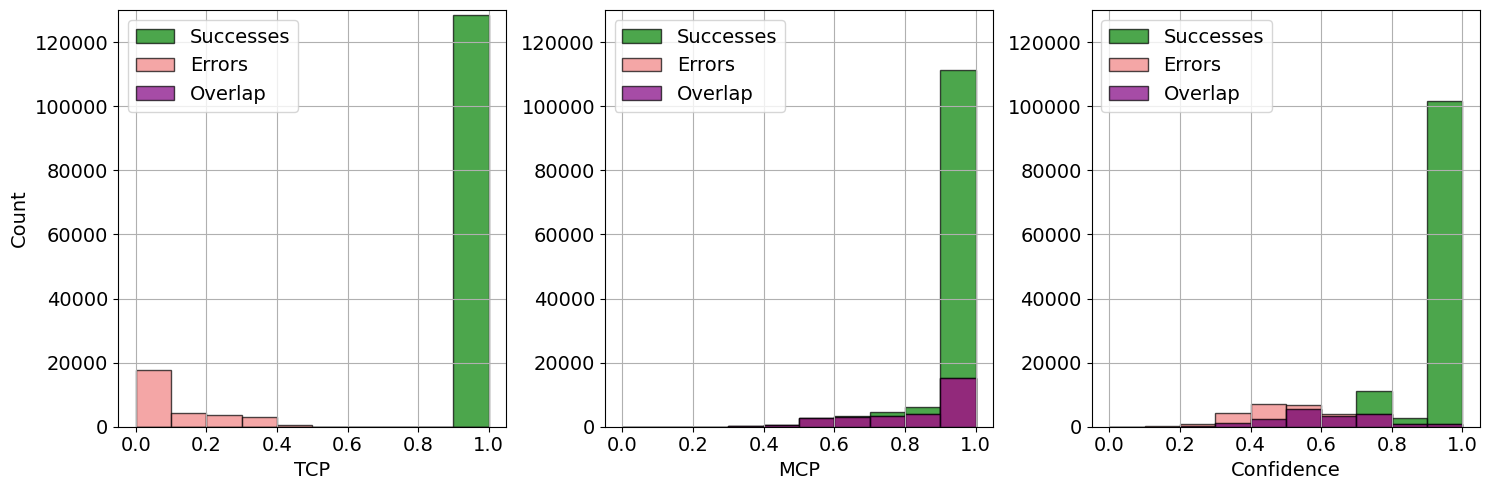

In [64]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# Assuming df is your DataFrame with relevant columns
df = pd.read_csv('confidence_estimates.csv')  # Replace with the actual file path

# Define successes and errors for each metric
successes_yc_star = df[df['ground_truth'] == df['prediction']]['yc_star']
errors_yc_star = df[df['ground_truth'] != df['prediction']]['yc_star']
successes_predicted = df[df['ground_truth'] == df['prediction']]['p(predicted class)']
errors_predicted = df[df['ground_truth'] != df['prediction']]['p(predicted class)']
successes_confidence = df[df['ground_truth'] == df['prediction']]['confidence']
errors_confidence = df[df['ground_truth'] != df['prediction']]['confidence']

# Define bins
bins = np.linspace(0, 1, 11)  # 10 bins between 0 and 1

# Compute histogram values for each metric
# TCP (yc_star)
success_hist_yc_star, _ = np.histogram(successes_yc_star, bins=bins)
error_hist_yc_star, _ = np.histogram(errors_yc_star, bins=bins)
overlap_hist_yc_star = np.minimum(success_hist_yc_star, error_hist_yc_star)

# MCP (p(predicted class))
success_hist_predicted, _ = np.histogram(successes_predicted, bins=bins)
error_hist_predicted, _ = np.histogram(errors_predicted, bins=bins)
overlap_hist_predicted = np.minimum(success_hist_predicted, error_hist_predicted)

# Confidence
success_hist_confidence, _ = np.histogram(successes_confidence, bins=bins)
error_hist_confidence, _ = np.histogram(errors_confidence, bins=bins)
overlap_hist_confidence = np.minimum(success_hist_confidence, error_hist_confidence)

# Plotting
plt.figure(figsize=(15, 5))
y_ticks = np.arange(0, 130001, 20000)

# TCP Histogram
plt.subplot(1, 3, 1)
plt.bar(bins[:-1], success_hist_yc_star, width=np.diff(bins), align='edge', color='green', edgecolor='black', label='Successes', alpha=0.7)
plt.bar(bins[:-1], error_hist_yc_star, width=np.diff(bins), align='edge', color='lightcoral', edgecolor='black', label='Errors', alpha=0.7)
plt.bar(bins[:-1], overlap_hist_yc_star, width=np.diff(bins), align='edge', color='purple', edgecolor='black', label='Overlap', alpha=0.7)
plt.xlabel('TCP', fontsize=14)
plt.ylabel('Count', fontsize=14)
plt.legend(loc='upper left', fontsize=14)
plt.ylim(0, 130000)
plt.grid(True)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)

# MCP Histogram
plt.subplot(1, 3, 2)
plt.bar(bins[:-1], success_hist_predicted, width=np.diff(bins), align='edge', color='green', edgecolor='black', label='Successes', alpha=0.7)
plt.bar(bins[:-1], error_hist_predicted, width=np.diff(bins), align='edge', color='lightcoral', edgecolor='black', label='Errors', alpha=0.7)
plt.bar(bins[:-1], overlap_hist_predicted, width=np.diff(bins), align='edge', color='purple', edgecolor='black', label='Overlap', alpha=0.7)
plt.xlabel('MCP', fontsize=14)
plt.legend(loc='upper left', fontsize=14)
plt.ylim(0, 130000)
plt.grid(True)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)

# Confidence Histogram
plt.subplot(1, 3, 3)
plt.bar(bins[:-1], success_hist_confidence, width=np.diff(bins), align='edge', color='green', edgecolor='black', label='Successes', alpha=0.7)
plt.bar(bins[:-1], error_hist_confidence, width=np.diff(bins), align='edge', color='lightcoral', edgecolor='black', label='Errors', alpha=0.7)
plt.bar(bins[:-1], overlap_hist_confidence, width=np.diff(bins), align='edge', color='purple', edgecolor='black', label='Overlap', alpha=0.7)
plt.xlabel('Confidence', fontsize=14)
plt.legend(loc='upper left', fontsize=14)
plt.ylim(0, 130000)
plt.grid(True)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)

# Adjust layout and save/show the figure
plt.tight_layout()
plt.savefig(f'Combined_Successes_vs_Errors_Histogram_{timestamp}.pdf', format='pdf')
plt.show()


In [65]:
from sklearn.metrics import classification_report

In [66]:
# !jupyter nbconvert --to script 'confidence_training.ipynb'

In [67]:
X_test.shape, Y_test.shape

((70, 12, 431), (70, 431))

In [68]:
y_cat_test = tf.keras.utils.to_categorical(Y_test,num_classes)

In [69]:
conf_values = confidnet_model.predict(X_test.transpose(0,2,1))

3/3 [==============================] - 0s 156ms/step


In [70]:
conf_values.shape

(70, 431, 1)

In [71]:
conf_values = np.reshape(conf_values, -1)

In [72]:
conf_values.shape

(30170,)

In [73]:
num_classes = 7
# y_cat_test = to_categorical(Y_test,num_classes)
y_pred = TCN_model.predict(X_test.transpose(0,2,1))
y_pred_classes = np.argmax(y_pred, axis=2)
y_pred_one_hot = np.eye(num_classes)[y_pred_classes]
y_test = np.reshape(y_cat_test, (-1, num_classes))
y_pred = np.reshape(y_pred_one_hot, (-1, num_classes))

3/3 [==============================] - 0s 5ms/step


In [74]:
y_test.shape, y_pred.shape

((30170, 7), (30170, 7))

In [75]:
report = classification_report(y_test, y_pred, target_names = ['No_concept', 'Kansvar', 'Meend', 'Andolan', 'murki' ,'Holding Note', 'Gamak'])

print(report)

              precision    recall  f1-score   support

  No_concept       0.95      0.76      0.85     23720
     Kansvar       0.32      0.67      0.44      1494
       Meend       0.40      0.63      0.49       655
     Andolan       0.63      0.74      0.68      1183
       murki       0.30      0.69      0.42       236
Holding Note       0.30      0.83      0.44      1384
       Gamak       0.83      0.71      0.76      1498

   micro avg       0.75      0.75      0.75     30170
   macro avg       0.53      0.72      0.58     30170
weighted avg       0.85      0.75      0.79     30170
 samples avg       0.75      0.75      0.75     30170



In [76]:
y_cat_test.shape, y_pred.shape, conf_values.shape

((70, 431, 7), (30170, 7), (30170,))

In [77]:
y_cat_test = np.reshape(y_cat_test, (-1, num_classes))

In [78]:
y_cat_test.shape, y_pred.shape, conf_values.shape

((30170, 7), (30170, 7), (30170,))

In [79]:
# Mask to filter indices where confidence is above the threshold
high_conf_indices = conf_values >= 0.3

# Apply the mask to filter y_cat_test and y_pred
filtered_Y_test = np.argmax(y_cat_test[high_conf_indices], axis=1)  # Convert one-hot encoded y_cat_test to class labels
filtered_tcn_pred = np.argmax(y_pred[high_conf_indices], axis=1)  # Convert softmax probabilities to class labels

# Generate the classification report
report = classification_report(
    filtered_Y_test,
    filtered_tcn_pred,
    target_names=['No_concept', 'Kanswar', 'Meend', 'Andolan', 'murki', 'Holding Note', 'Gamak']
)

print(report)

              precision    recall  f1-score   support

  No_concept       0.95      0.77      0.85     23438
     Kanswar       0.32      0.68      0.44      1479
       Meend       0.44      0.63      0.52       650
     Andolan       0.68      0.73      0.70      1163
       murki       0.34      0.66      0.45       214
Holding Note       0.30      0.83      0.44      1384
       Gamak       0.83      0.72      0.77      1489

    accuracy                           0.76     29817
   macro avg       0.55      0.72      0.60     29817
weighted avg       0.86      0.76      0.79     29817



In [80]:
30170-24759

5411

In [81]:
filtered_Y_test.shape, filtered_tcn_pred.shape, high_conf_indices.shape, conf_values.shape

((29817,), (29817,), (30170,), (30170,))

In [90]:
# filtered_tcn_pred[5000:5500]

In [82]:
import numpy as np

def compute_ece(y_true, y_pred, confidences, n_bins=10):
    # Initialize ECE
    ece = 0.0
    bin_size = 1.0 / n_bins

    for i in range(n_bins):
        # Define bin range
        bin_lower = i * bin_size
        bin_upper = (i + 1) * bin_size

        # Select indices of predictions within the bin range
        bin_indices = np.where((confidences >= bin_lower) & (confidences < bin_upper))[0]

        if len(bin_indices) > 0:
            # Accuracy within the bin
            bin_accuracy = np.mean(y_pred[bin_indices] == y_true[bin_indices])
            # Mean confidence within the bin
            bin_confidence = np.mean(confidences[bin_indices])
            # Bin weight
            bin_weight = len(bin_indices) / len(confidences)

            # Accumulate weighted absolute difference for ECE
            ece += bin_weight * abs(bin_confidence - bin_accuracy)

    return ece

# Example usage
ece = compute_ece(filtered_Y_test, filtered_tcn_pred, conf_values[high_conf_indices], n_bins=10)
print(f"ECE: {ece:.4f}")


ECE: 0.0767


In [84]:
type(conf_values), conf_values.shape

(numpy.ndarray, (30170,))

In [83]:
# Example usage
ece = compute_ece(filtered_Y_test, filtered_tcn_pred, conf_values[high_conf_indices], n_bins=10)
print(f"ECE: {ece:.4f}")


ECE: 0.0767


In [85]:
type(high_conf_indices), high_conf_indices.shape

(numpy.ndarray, (30170,))